# Hyperparameter Analysis (Baseline)

Analyze which genetic algorithm hyperparameters matter for route cost,
starting from individual effects, with conditional plots to avoid masking interactions.

**Design decisions:**
- GD iterations analyzed separately (independent post-processing)
- Hazard penalty fixed at 0
- Runtime ignored (parallelism makes it irrelevant)
- Adaptation scales conditioned on `enable_adaptation=True`
- Crossover strategy conditioned on `crossover_rounds > 0`
- Raw cost (TJ), no normalization

**8 representative cases** (2 months x 2 directions x 2 speeds):

| Case | Regime | Key feature |
|------|--------|-------------|
| Aug E 8kn | current-dominated | GS attached, strong current exploitation |
| Aug E 12kn | current, reduced | Less GS attachment at higher speed |
| Aug W 8kn | calm, slow | Avoid GS, long duration |
| Aug W 12kn | calm, fast | Avoid GS, short duration |
| Jan E 8kn | wave + current | Winter storms with GS exploitation |
| Jan E 12kn | wave-dominated | Winter storms, less current benefit |
| Jan W 8kn | wave detour, slow | Wave avoidance, long exposure |
| Jan W 12kn | wave detour, fast | Wave avoidance, short exposure |

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from load_tuning_results import add_derived_features, filter_suspicious_routes

warnings.filterwarnings("ignore")

sns.set_context("paper", font_scale=1.6)
sns.set_style("whitegrid")

In [2]:
CASES = [
    {"month": "Aug", "direction": "eastward", "speed": 8, "label": "Aug E 8kn"},
    {"month": "Aug", "direction": "eastward", "speed": 12, "label": "Aug E 12kn"},
    {"month": "Aug", "direction": "westward", "speed": 8, "label": "Aug W 8kn"},
    {"month": "Aug", "direction": "westward", "speed": 12, "label": "Aug W 12kn"},
    {"month": "Jan", "direction": "eastward", "speed": 8, "label": "Jan E 8kn"},
    {"month": "Jan", "direction": "eastward", "speed": 12, "label": "Jan E 12kn"},
    {"month": "Jan", "direction": "westward", "speed": 8, "label": "Jan W 8kn"},
    {"month": "Jan", "direction": "westward", "speed": 12, "label": "Jan W 12kn"},
]

GENETIC_PARAMS = [
    "hyper_population_size",
    "hyper_offspring_size",
    "hyper_generations",
    "hyper_mutation_iterations",
    "hyper_crossover_rounds",
    "hyper_crossover_strategy",
    "hyper_selection_quantile",
    "hyper_selection_acceptance_rate",
    "hyper_enable_adaptation",
    "hyper_adaptation_scale_W",
    "hyper_adaptation_scale_D",
    "hyper_mutation_displacement_fraction_warmup",
]

PARAM_SHORT = {
    "hyper_population_size": "pop_size",
    "hyper_offspring_size": "offspring",
    "hyper_generations": "generations",
    "hyper_mutation_iterations": "mut_iters",
    "hyper_crossover_rounds": "xover_rounds",
    "hyper_crossover_strategy": "xover_strategy",
    "hyper_selection_quantile": "sel_quantile",
    "hyper_selection_acceptance_rate": "sel_accept",
    "hyper_enable_adaptation": "adaptation",
    "hyper_adaptation_scale_W": "adapt_W",
    "hyper_adaptation_scale_D": "adapt_D",
    "hyper_mutation_displacement_fraction_warmup": "warmup_D",
}

FIG_DIR = "../figures"

## Load and filter data

In [3]:
gdf = gpd.read_parquet("../results/results_prelim.geoparquet")
gdf = add_derived_features(gdf)
gdf = filter_suspicious_routes(gdf)

# Baseline forcing, no hazard penalty, best elite only
gdf = gdf[
    (gdf.forcing_scenario_name == "baseline")
    & (gdf.hyper_hazard_penalty_multiplier == 0.0)
    & (gdf.n_elite == 0)
].copy()

gdf["month"] = pd.to_datetime(gdf.journey_time_start.astype(str)).dt.month_name().str[:3]
gdf["direction"] = gdf.journey_name.map(
    {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
)

print(f"Rows after filtering: {len(gdf)}")

0.57% suspicious routes
Rows after filtering: 19143


In [4]:
case_dfs = {}
for case in CASES:
    mask = (
        (gdf.month == case["month"])
        & (gdf.direction == case["direction"])
        & (gdf.journey_speed_knots == case["speed"])
    )
    case_dfs[case["label"]] = gdf[mask].copy()
    print(f"{case['label']}: {mask.sum()} configs")

# Build long-form DataFrame with case label for seaborn faceting
case_labels = [c["label"] for c in CASES]
case_frames = []
for label, df in case_dfs.items():
    df = df.copy()
    df["case"] = label
    df["cost_TJ"] = df["elite_cost_absolute"] / 1e12
    case_frames.append(df)
all_cases = pd.concat(case_frames, ignore_index=True)

# Consistent case palette
CASE_PALETTE = dict(zip(case_labels, sns.color_palette(n_colors=len(case_labels))))

# Subset: genetic only (gd=0)
gen_only = all_cases[all_cases.hyper_gd_iterations == 0].copy()

# Helper: create ordered categorical from numeric column
def ordered_cat(series):
    vals = sorted(series.dropna().unique())
    return pd.Categorical(series.astype(str), categories=[str(v) for v in vals], ordered=True)

print(f"\nAll cases combined: {len(all_cases)} rows")
print(f"Genetic only (gd=0): {len(gen_only)} rows")

Aug E 8kn: 248 configs
Aug E 12kn: 291 configs
Aug W 8kn: 252 configs
Aug W 12kn: 309 configs
Jan E 8kn: 212 configs
Jan E 12kn: 304 configs
Jan W 8kn: 261 configs
Jan W 12kn: 307 configs

All cases combined: 2184 rows
Genetic only (gd=0): 1132 rows


## Part 1: GD iterations (independent)

Gradient descent is pure post-processing on elites. Analyze separately.

In [5]:
for label, df in case_dfs.items():
    stats = df.groupby("hyper_gd_iterations")["elite_cost_absolute"].agg(
        ["median", "mean", "count"]
    )
    stats[["median", "mean"]] /= 1e12
    print(f"\n{label} (TJ):")
    print(stats.round(3).to_string())


Aug E 8kn (TJ):
                     median   mean  count
hyper_gd_iterations                      
0.0                   2.245  2.218    137
2.0                   2.215  2.188    111

Aug E 12kn (TJ):
                     median   mean  count
hyper_gd_iterations                      
0.0                   5.459  5.371    152
2.0                   5.328  5.245    139

Aug W 8kn (TJ):
                     median   mean  count
hyper_gd_iterations                      
0.0                   3.363  3.364    123
2.0                   3.282  3.329    129

Aug W 12kn (TJ):
                     median  mean  count
hyper_gd_iterations                     
0.0                   5.228  5.23    159
2.0                   5.169  5.16    150

Jan E 8kn (TJ):
                     median   mean  count
hyper_gd_iterations                      
0.0                   9.109  9.085    111
2.0                   9.076  9.037    101

Jan E 12kn (TJ):
                     median    mean  count
hyper_gd_iterati

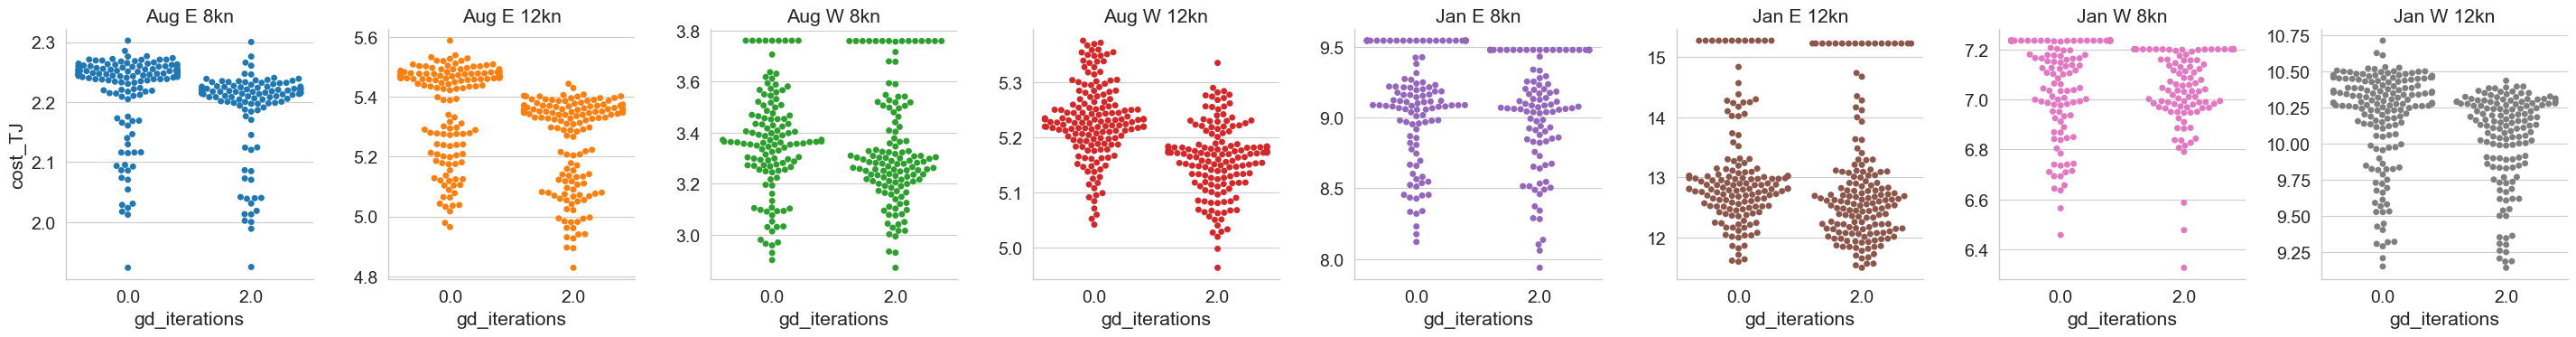

In [6]:
all_cases["gd_iterations"] = ordered_cat(all_cases.hyper_gd_iterations)

g = sns.catplot(
    data=all_cases,
    x="gd_iterations",
    y="cost_TJ",
    hue="case",
    col="case",
    kind="swarm",
    height=4,
    aspect=0.9,
    sharey=False,
    legend=False,
    palette=CASE_PALETTE,
)
g.set_titles(col_template="{col_name}")
g.tight_layout()
g.savefig(f"{FIG_DIR}/031_gd_iterations.png", dpi=150)
g.savefig(f"{FIG_DIR}/031_gd_iterations.pdf", dpi=150)

## Part 2: Marginal parameter importance ranking

For each genetic param, compute median cost difference between its levels.
Adaptation scales conditioned on `adaptation=True`. GD fixed at 0.

**Effect size** = `(max_median - min_median) / overall_median * 100`,
where overall median is across all configs (gd=0) for that case.
This measures how much the parameter's best-vs-worst level shifts
cost relative to a typical random configuration.

In [7]:
importance_results = []

for label, df_full in case_dfs.items():
    df = df_full[df_full.hyper_gd_iterations == 0].copy()

    for param in GENETIC_PARAMS:
        # Condition adaptation scales on adaptation=True
        if param in ("hyper_adaptation_scale_W", "hyper_adaptation_scale_D"):
            df_p = df[df.hyper_enable_adaptation == True]
        else:
            df_p = df

        if df_p[param].nunique() < 2:
            continue

        medians = df_p.groupby(param)["elite_cost_absolute"].median()
        effect = (medians.max() - medians.min()) / df["elite_cost_absolute"].median()

        importance_results.append({
            "case": label,
            "param": PARAM_SHORT.get(param, param),
            "effect_pct": effect * 100,
            "best_value": medians.idxmin(),
        })

importance_df = pd.DataFrame(importance_results)

In [8]:
for label in case_dfs:
    sub = importance_df[importance_df.case == label].sort_values("effect_pct", ascending=False)
    print(f"\n{label}:")
    print(sub[["param", "effect_pct", "best_value"]].to_string(index=False))


Aug E 8kn:
         param  effect_pct   best_value
   generations    1.798799          4.0
     offspring    1.024615        256.0
      pop_size    0.466332        256.0
       adapt_W    0.425269          0.5
       adapt_D    0.338328        0.894
xover_strategy    0.259725 minimal_cost
     mut_iters    0.182176          3.0
      warmup_D    0.170593          0.1
  xover_rounds    0.091964          1.0
    sel_accept    0.088992         0.25
  sel_quantile    0.086387          0.1
    adaptation    0.038619         True

Aug E 12kn:
         param  effect_pct   best_value
   generations    4.311099          4.0
     mut_iters    2.642366          3.0
     offspring    1.352453        256.0
      pop_size    0.681034        256.0
  xover_rounds    0.515754          2.0
      warmup_D    0.478253         0.25
  sel_quantile    0.244497         0.25
       adapt_D    0.076430        0.894
    adaptation    0.075104        False
xover_strategy    0.070179 minimal_cost
    sel_accept 

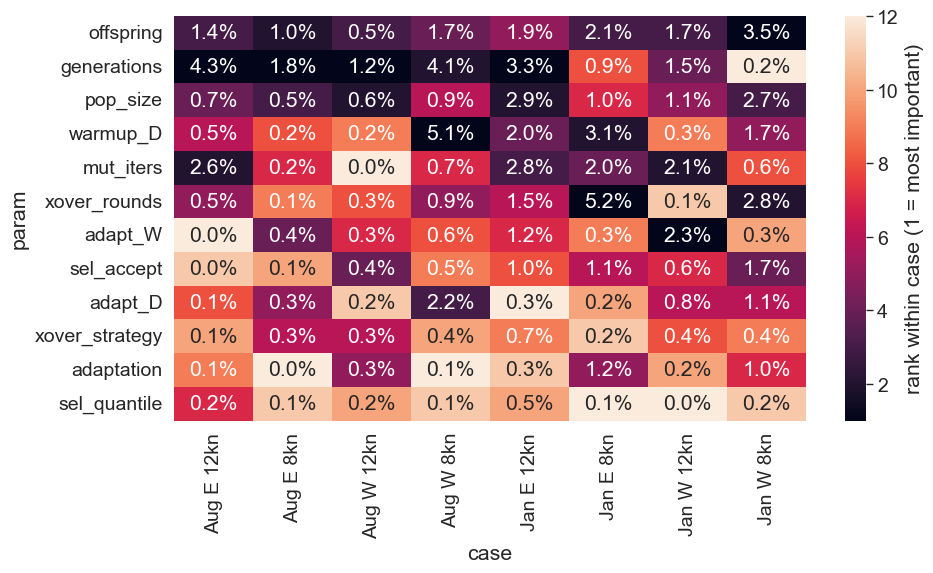

In [9]:
pivot = importance_df.pivot(index="param", columns="case", values="effect_pct")

# Rank within each case (column): 1 = most important
rank_pivot = pivot.rank(ascending=False)

# Sort rows by mean rank (most important params at top)
pivot = pivot.loc[rank_pivot.mean(axis=1).sort_values().index]
rank_pivot = rank_pivot.loc[pivot.index]

# Annotation matrix with % sign
annot = pivot.map(lambda x: f"{x:.1f}%")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    rank_pivot,
    annot=annot,
    fmt="",
    ax=ax,
    cbar_kws={"label": "rank within case (1 = most important)"},
)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/031_param_importance_heatmap.png", dpi=150)
fig.savefig(f"{FIG_DIR}/031_param_importance_heatmap.pdf", dpi=150)

## Part 3: Marginal distributions per parameter

One figure with all genetic parameters. Each subplot: parameter levels on x, cases as hue.
GD=0 throughout. Adaptation scales conditioned on `adaptation=True`.

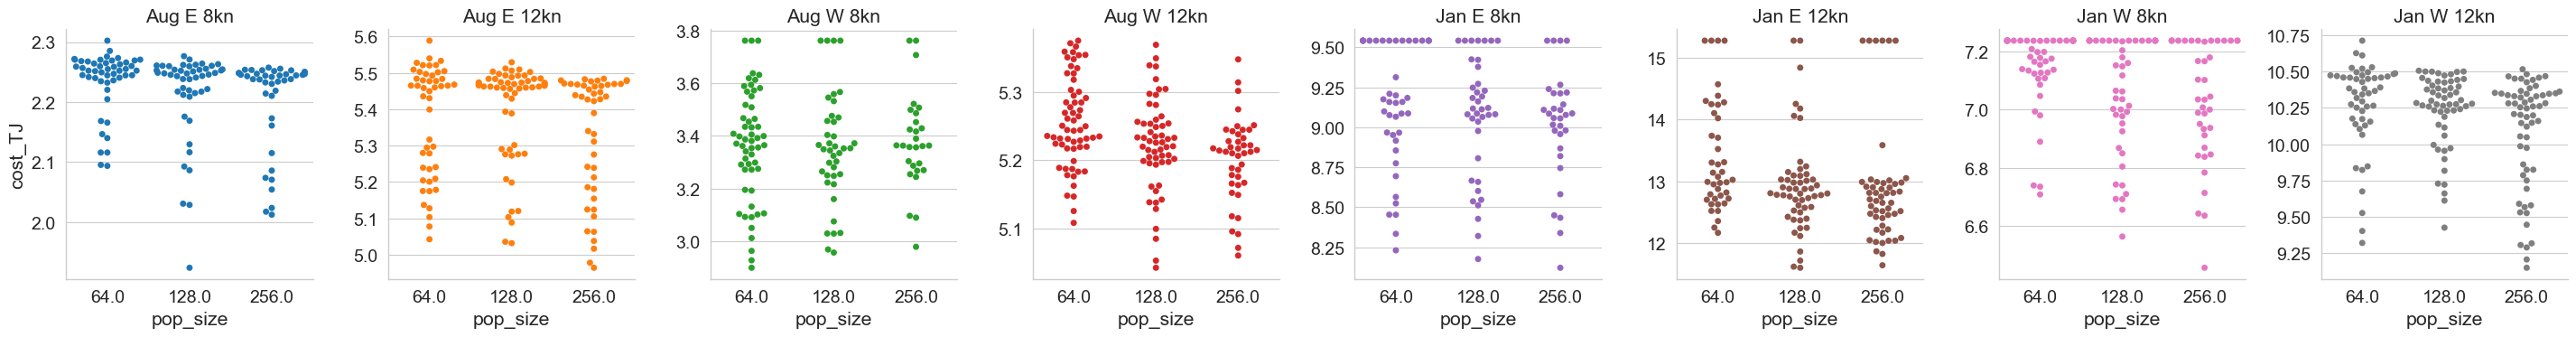

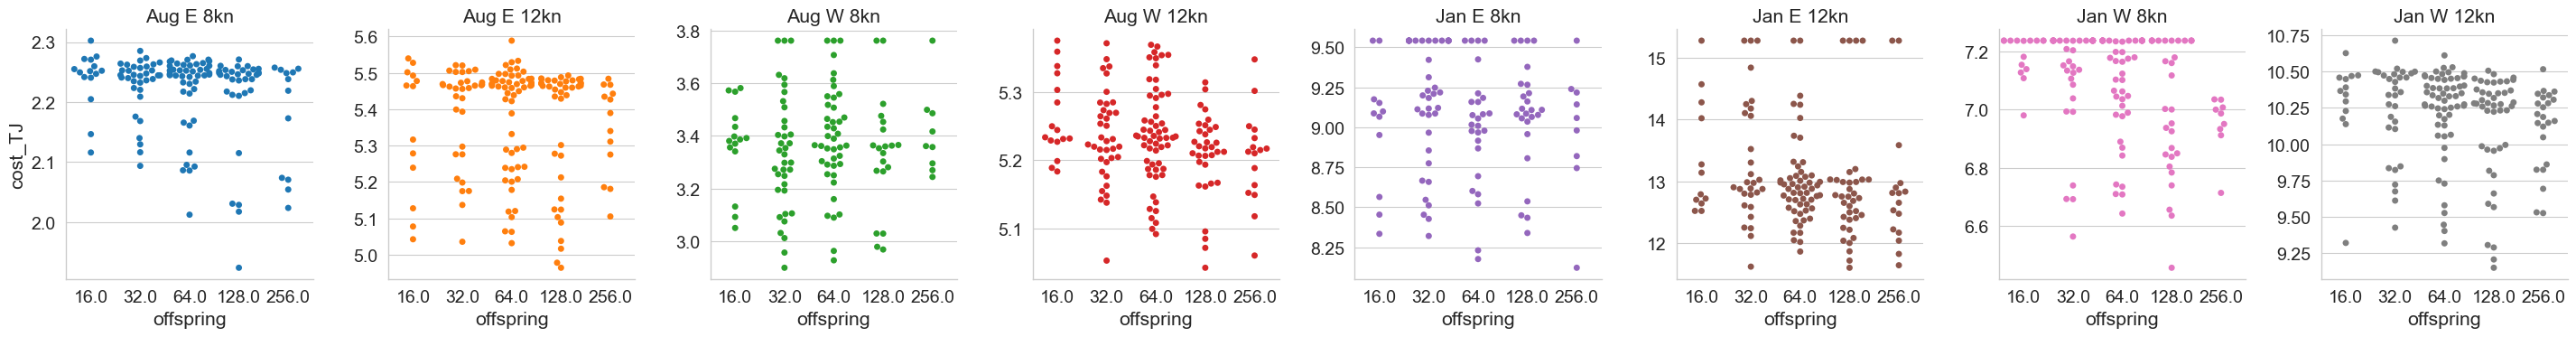

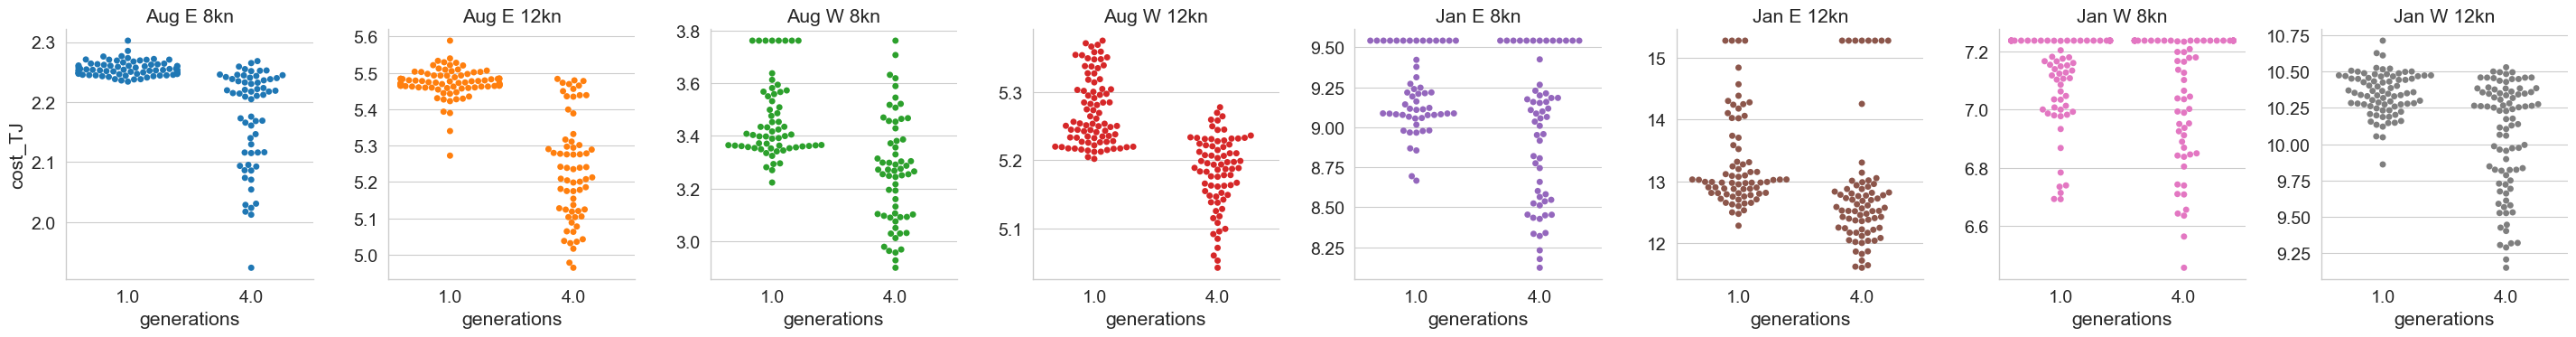

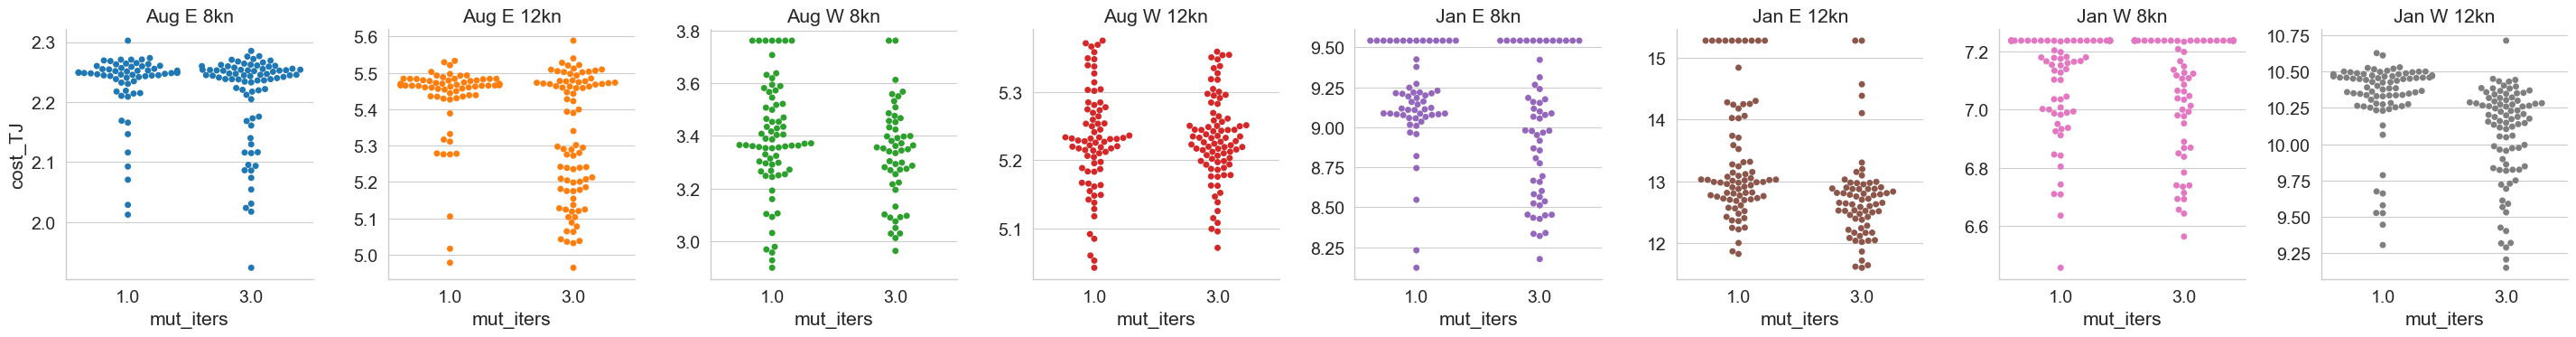

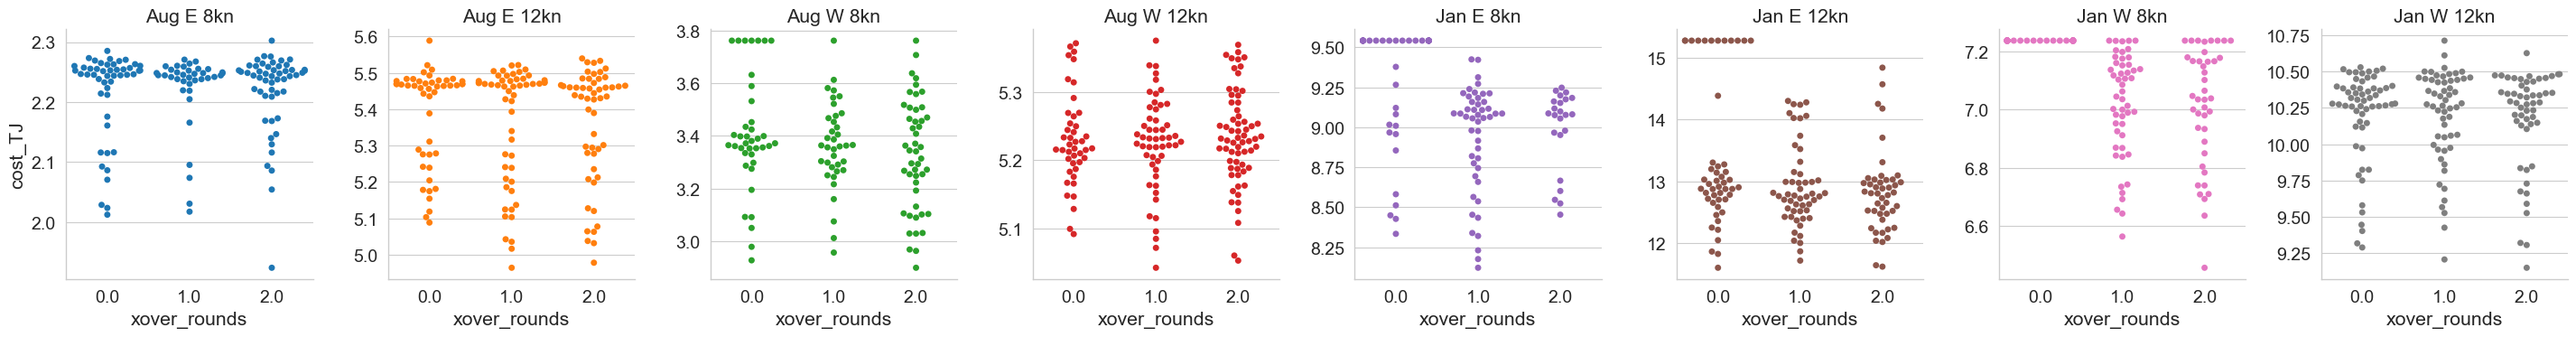

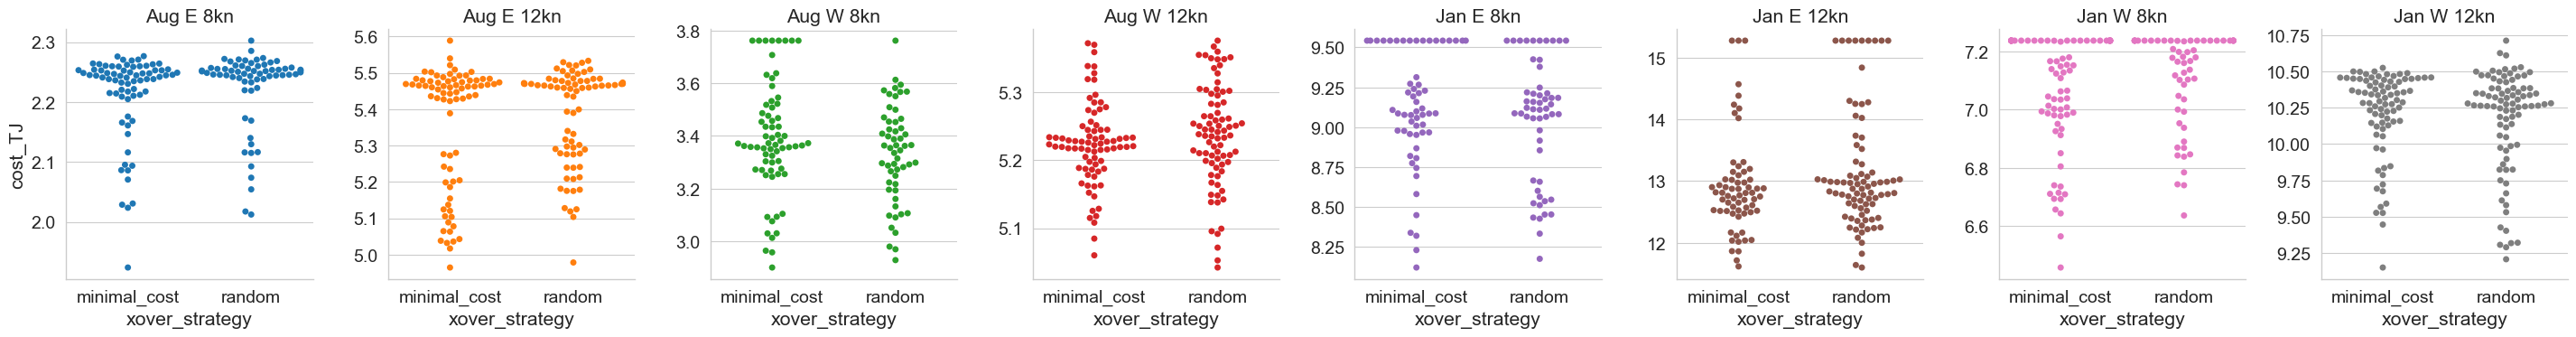

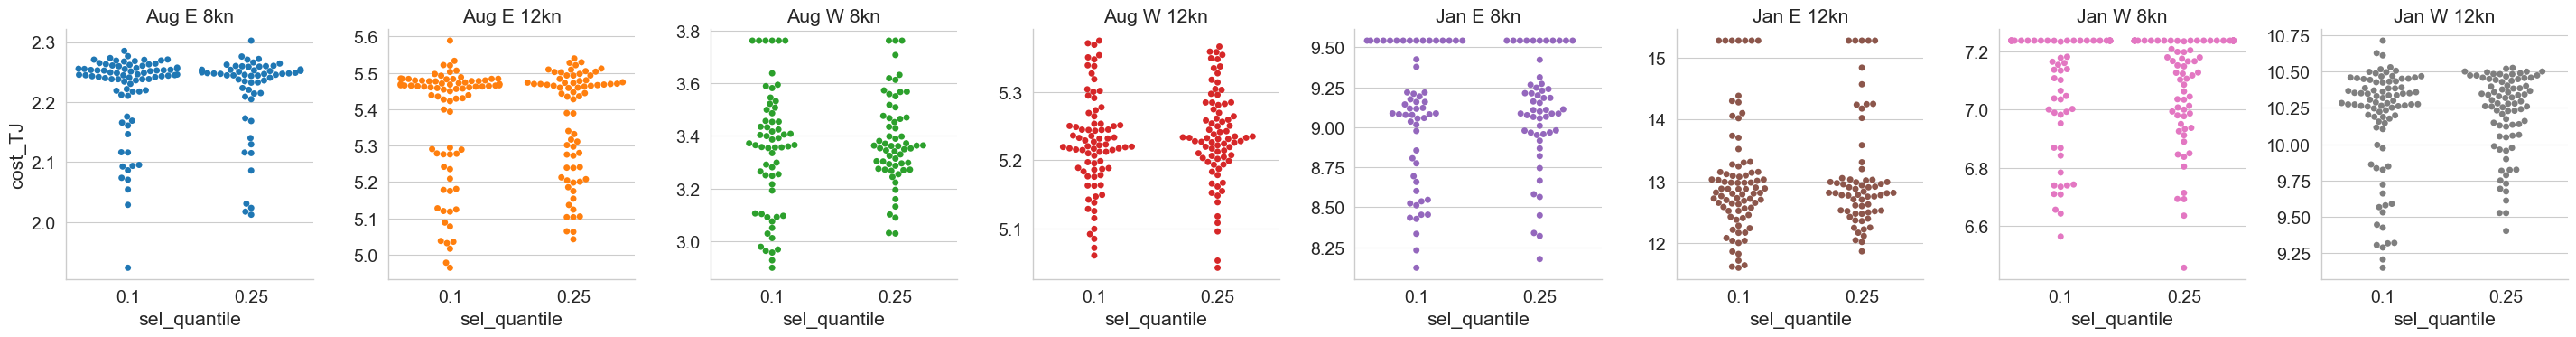

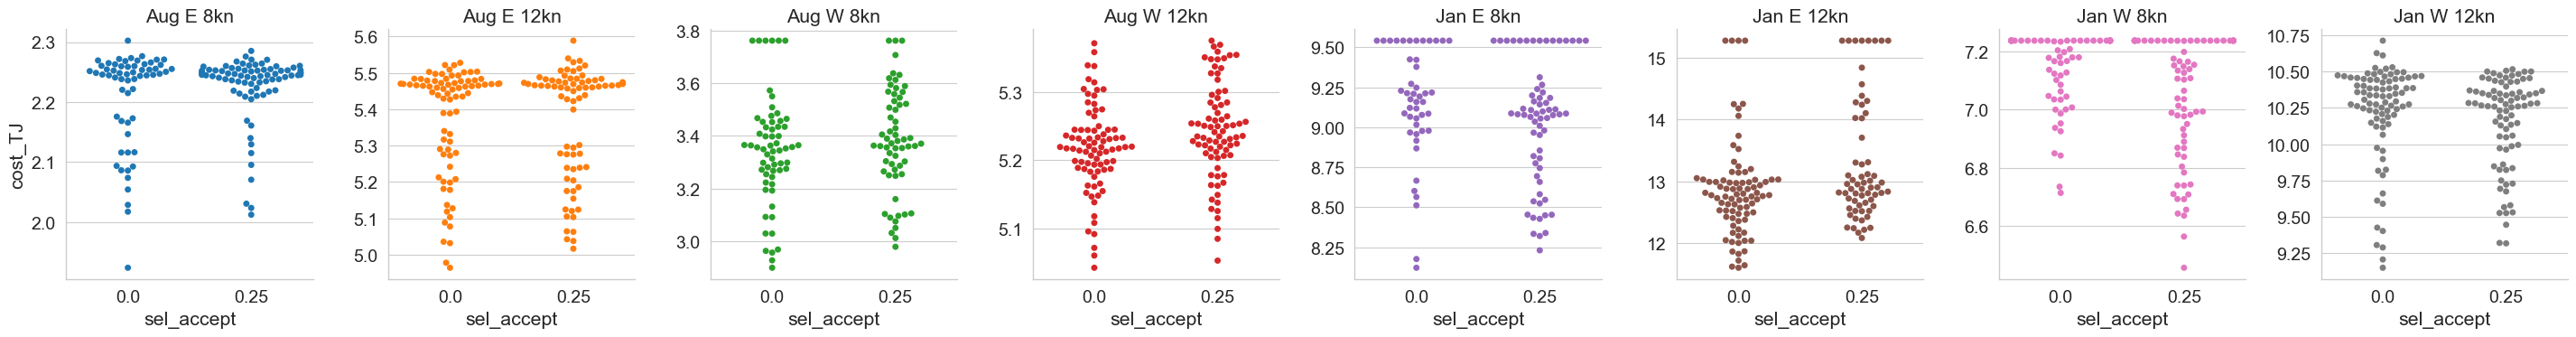

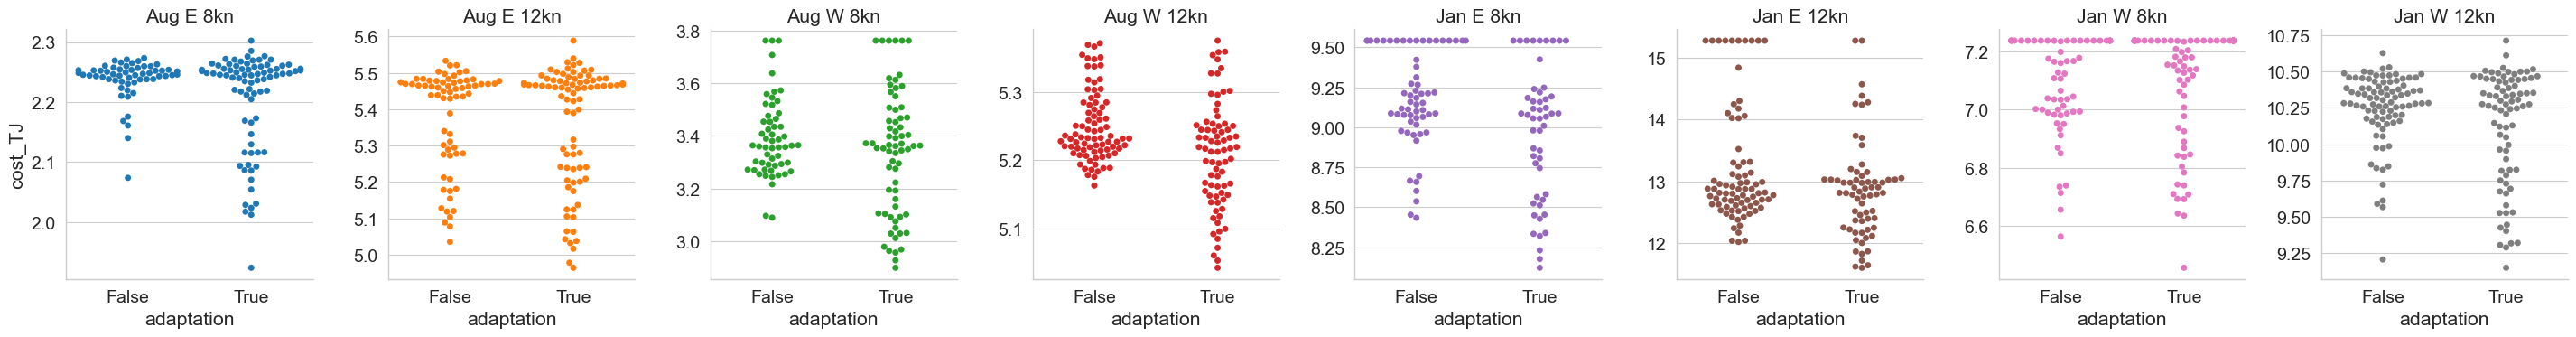

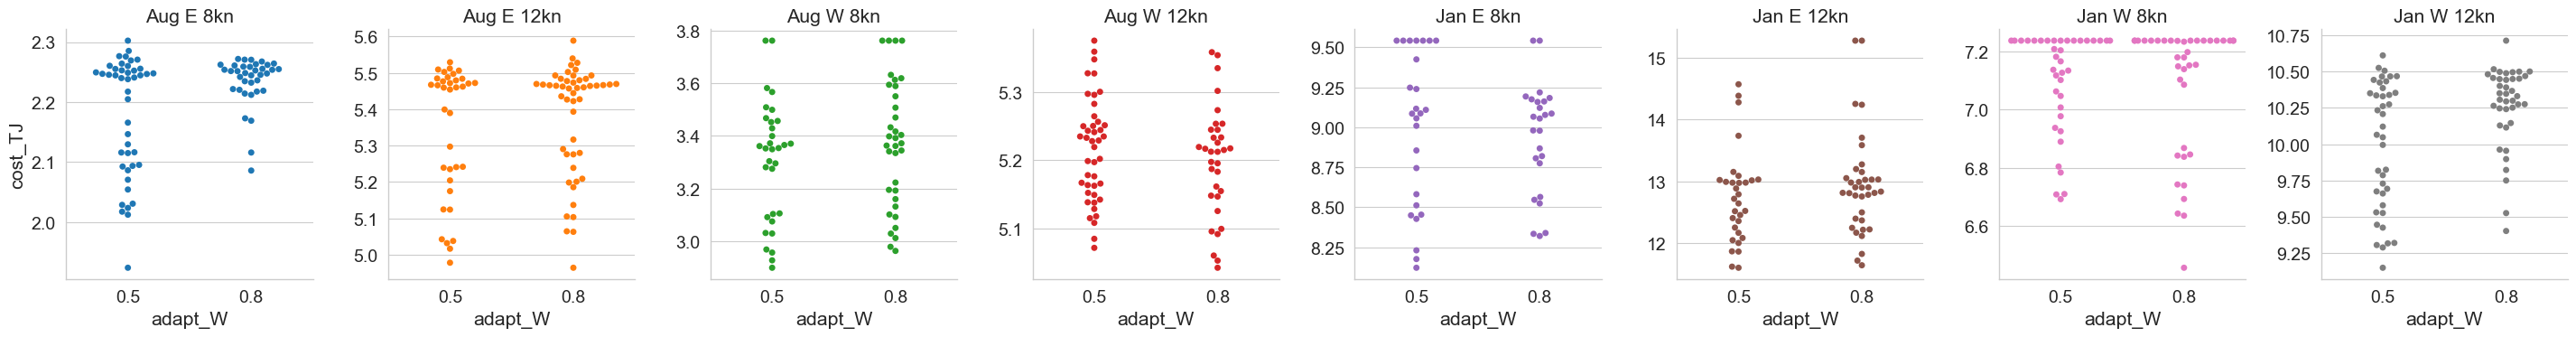

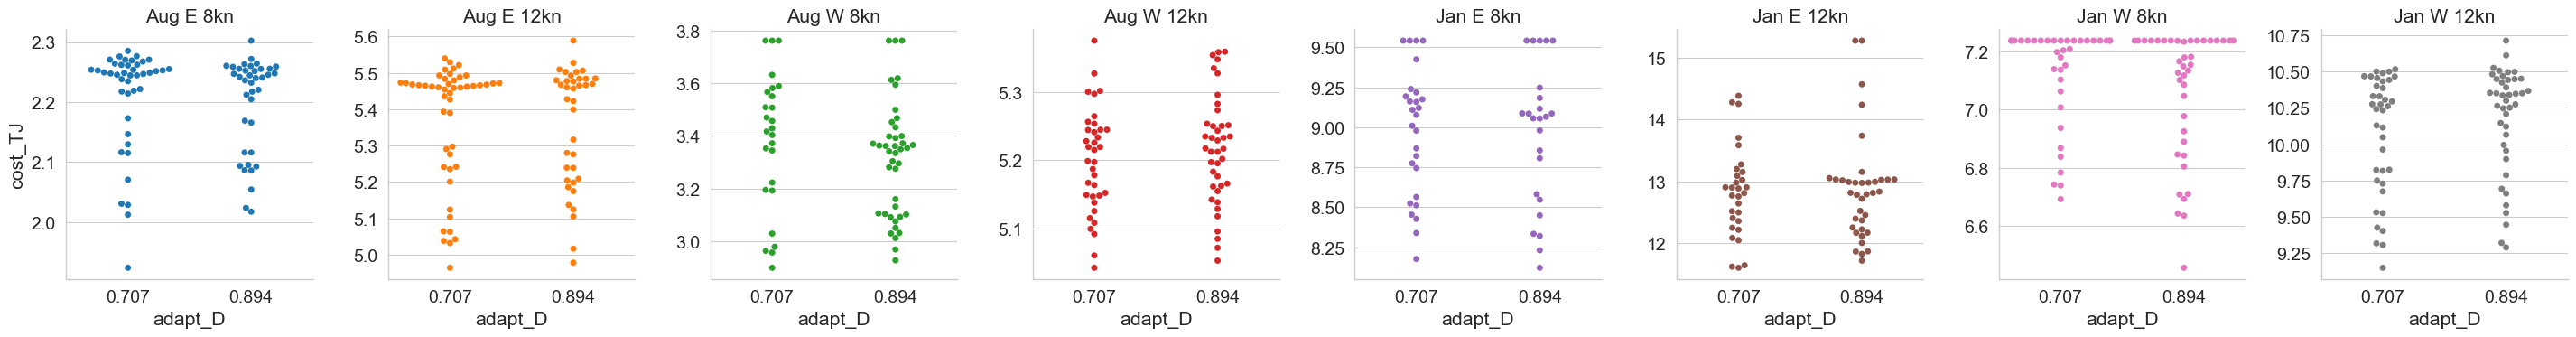

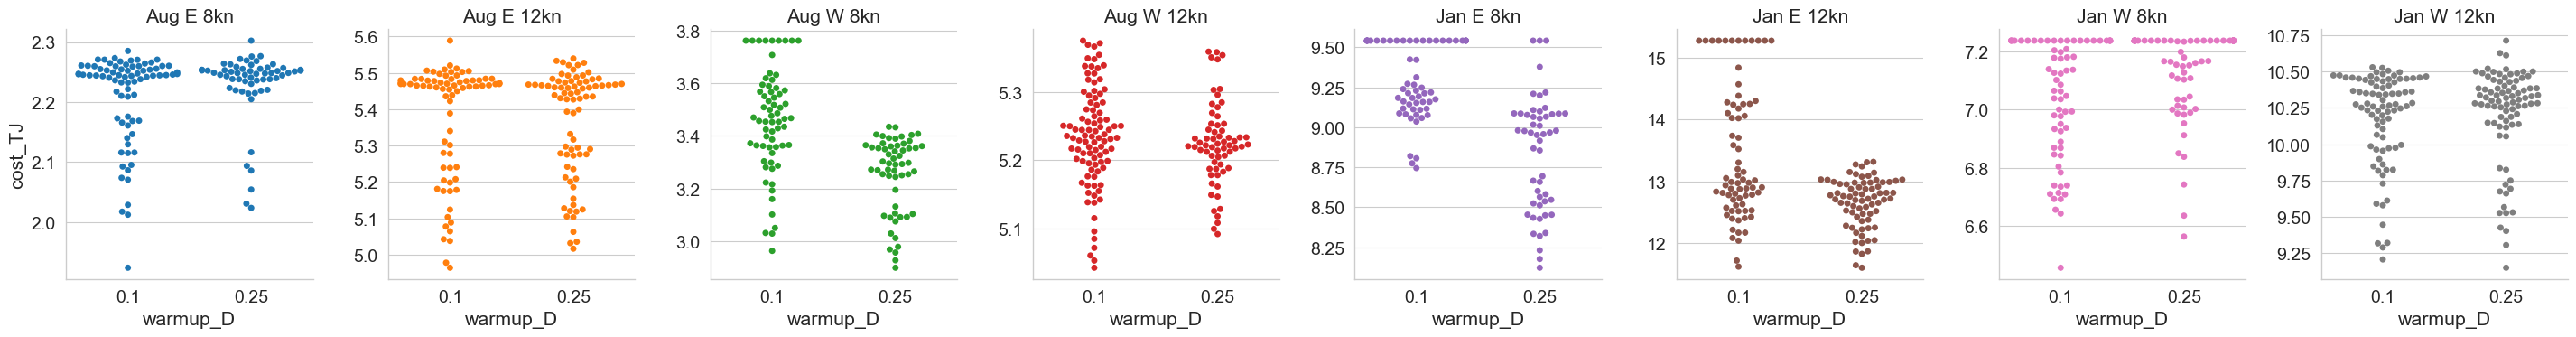

In [10]:
# Collect plottable params (skip single-value ones)
plot_params = []
for param in GENETIC_PARAMS:
    is_adapt = param in ("hyper_adaptation_scale_W", "hyper_adaptation_scale_D")
    df_check = gen_only[gen_only.hyper_enable_adaptation == True] if is_adapt else gen_only
    if df_check[param].nunique() >= 2:
        plot_params.append(param)

for param in plot_params:
    short = PARAM_SHORT.get(param, param)
    is_adapt = param in ("hyper_adaptation_scale_W", "hyper_adaptation_scale_D")

    plot_df = gen_only.copy()
    if is_adapt:
        plot_df = plot_df[plot_df.hyper_enable_adaptation == True]

    plot_df[short] = ordered_cat(plot_df[param])

    g = sns.catplot(
        data=plot_df,
        x=short,
        y="cost_TJ",
        hue="case",
        col="case",
        kind="swarm",
        height=4,
        aspect=0.9,
        sharey=False,
        legend=False,
        palette=CASE_PALETTE,
    )
    g.set_titles(col_template="{col_name}")
    g.tight_layout()
    g.savefig(f"{FIG_DIR}/031_marginal_{short}.png", dpi=150, bbox_inches="tight")
    g.savefig(f"{FIG_DIR}/031_marginal_{short}.pdf", dpi=150, bbox_inches="tight")
    plt.show()

## Part 4: Conditional plots (interaction-revealing)

Don't model interactions, but don't mask them either.
Show parameter effects conditioned on related parameters.

- `mutation_iterations` faceted by `generations`
- `mutation_iterations` faceted by `selection_acceptance_rate`
- `adaptation_scale_W` faceted by `mutation_iterations` (adaptation=True)
- `crossover_strategy` conditioned on `crossover_rounds > 0`

### 4a: mutation_iterations x generations

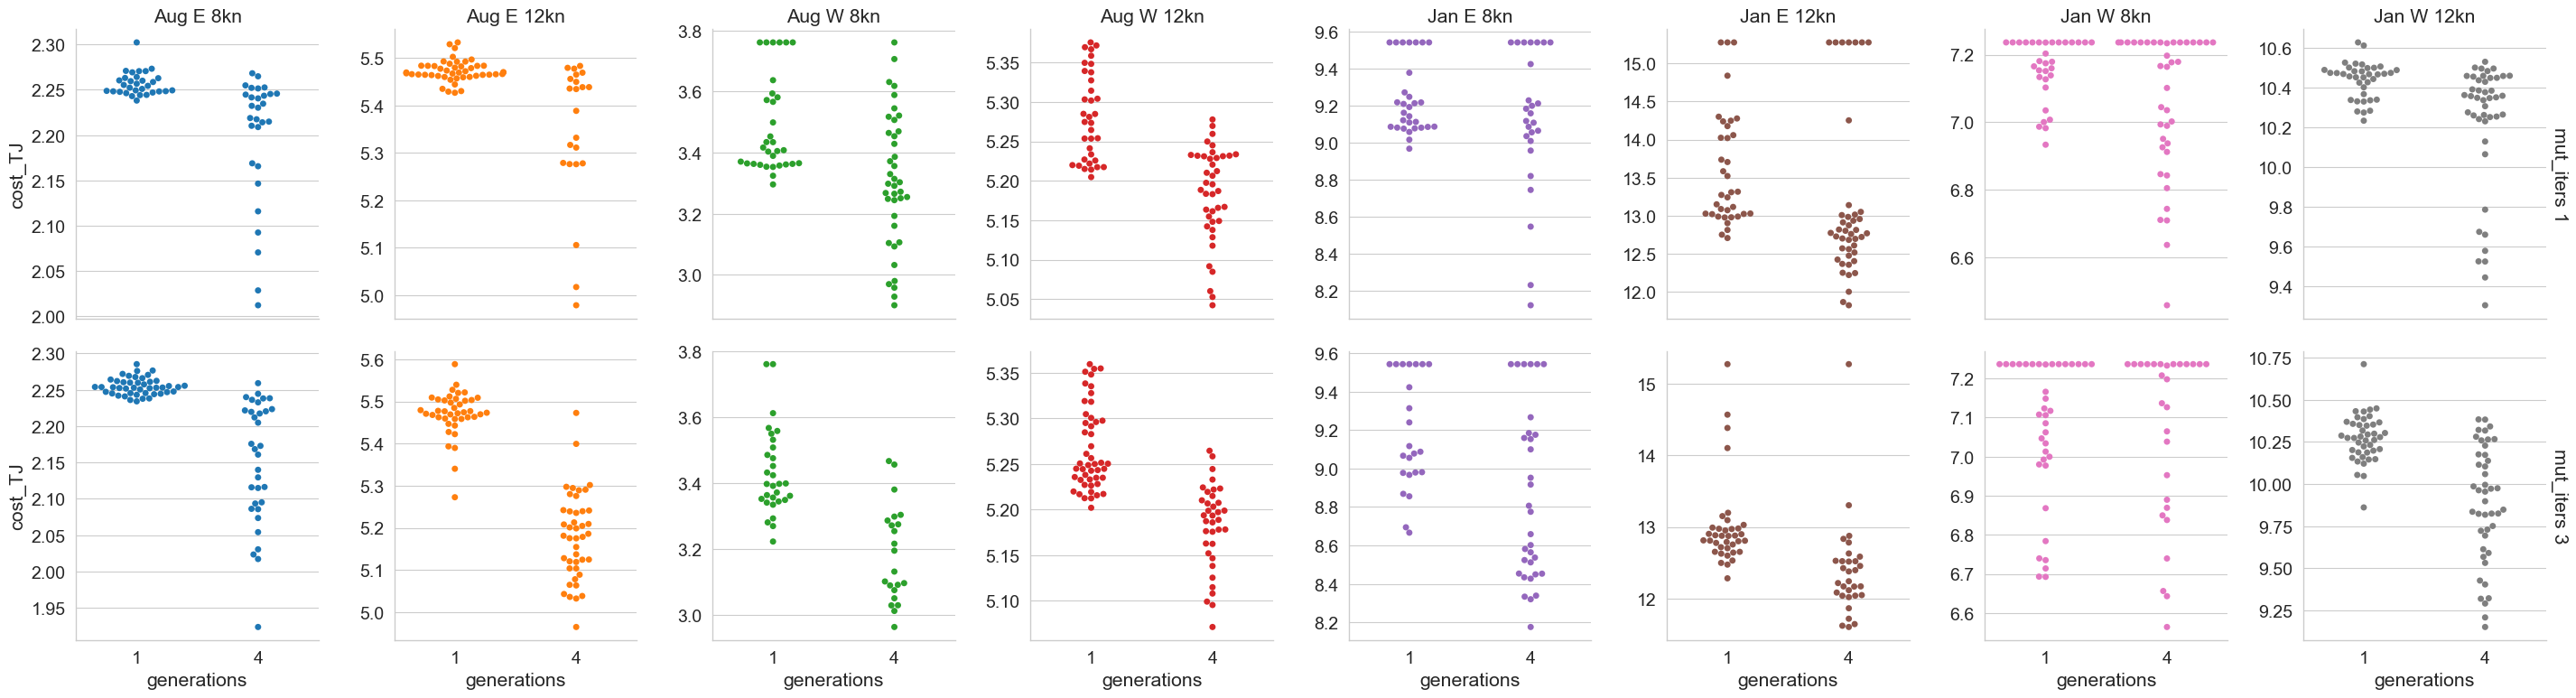

In [11]:
gen_only["mut_iters"] = ordered_cat(gen_only.hyper_mutation_iterations.astype(int))
gen_only["generations"] = ordered_cat(gen_only.hyper_generations.astype(int))

g = sns.catplot(
    data=gen_only,
    x="generations",
    y="cost_TJ",
    hue="case",
    col="case",
    row="mut_iters",
    kind="swarm",
    height=4,
    aspect=0.9,
    sharey=False,
    legend=False,
    palette=CASE_PALETTE,
    margin_titles=True,
)
g.set_titles(col_template="{col_name}", row_template="mut_iters {row_name}")
g.tight_layout()
g.savefig(f"{FIG_DIR}/031_cond_mut_iters_x_gen.png", dpi=150)
g.savefig(f"{FIG_DIR}/031_cond_mut_iters_x_gen.pdf", dpi=150)

### 4b: mutation_iterations x selection_acceptance_rate

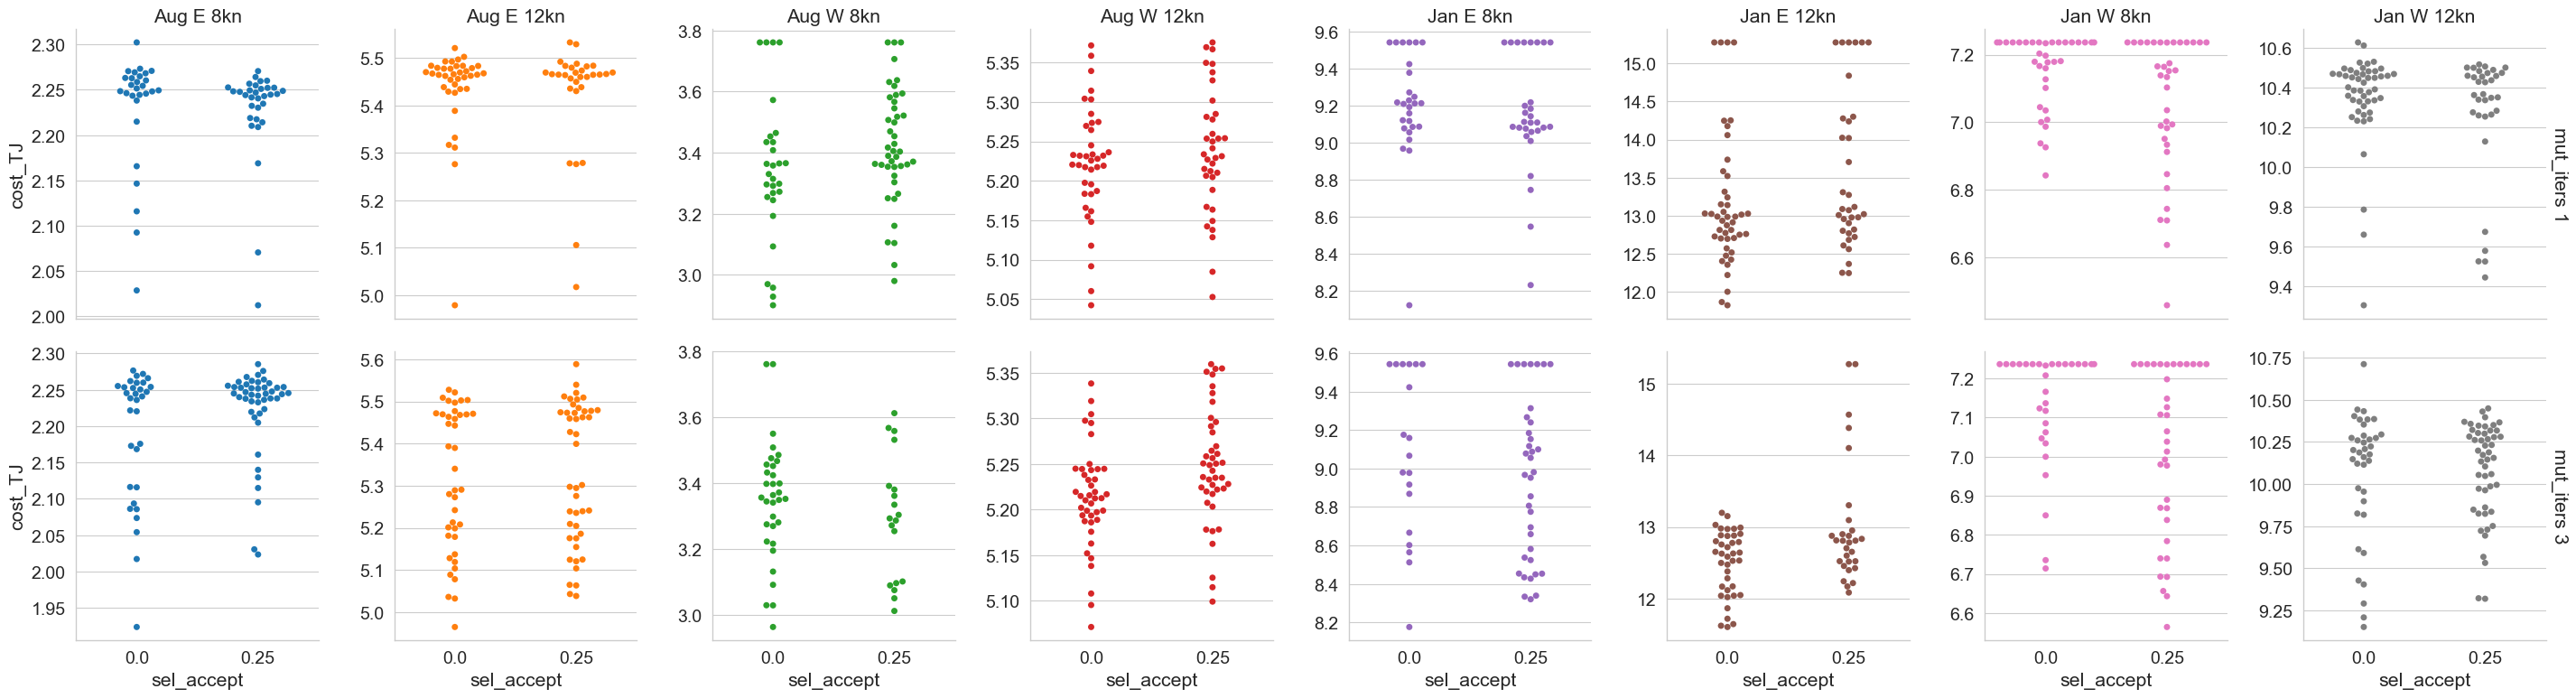

In [12]:
gen_only["sel_accept"] = ordered_cat(gen_only.hyper_selection_acceptance_rate)

g = sns.catplot(
    data=gen_only,
    x="sel_accept",
    y="cost_TJ",
    hue="case",
    col="case",
    row="mut_iters",
    kind="swarm",
    height=4,
    aspect=0.9,
    sharey=False,
    legend=False,
    palette=CASE_PALETTE,
    margin_titles=True,
)
g.set_titles(col_template="{col_name}", row_template="mut_iters {row_name}")
g.tight_layout()
g.savefig(f"{FIG_DIR}/031_cond_mut_iters_x_accept.png", dpi=150)
g.savefig(f"{FIG_DIR}/031_cond_mut_iters_x_accept.pdf", dpi=150)

### 4c: adaptation_scale_W x mutation_iterations (adaptation=True only)

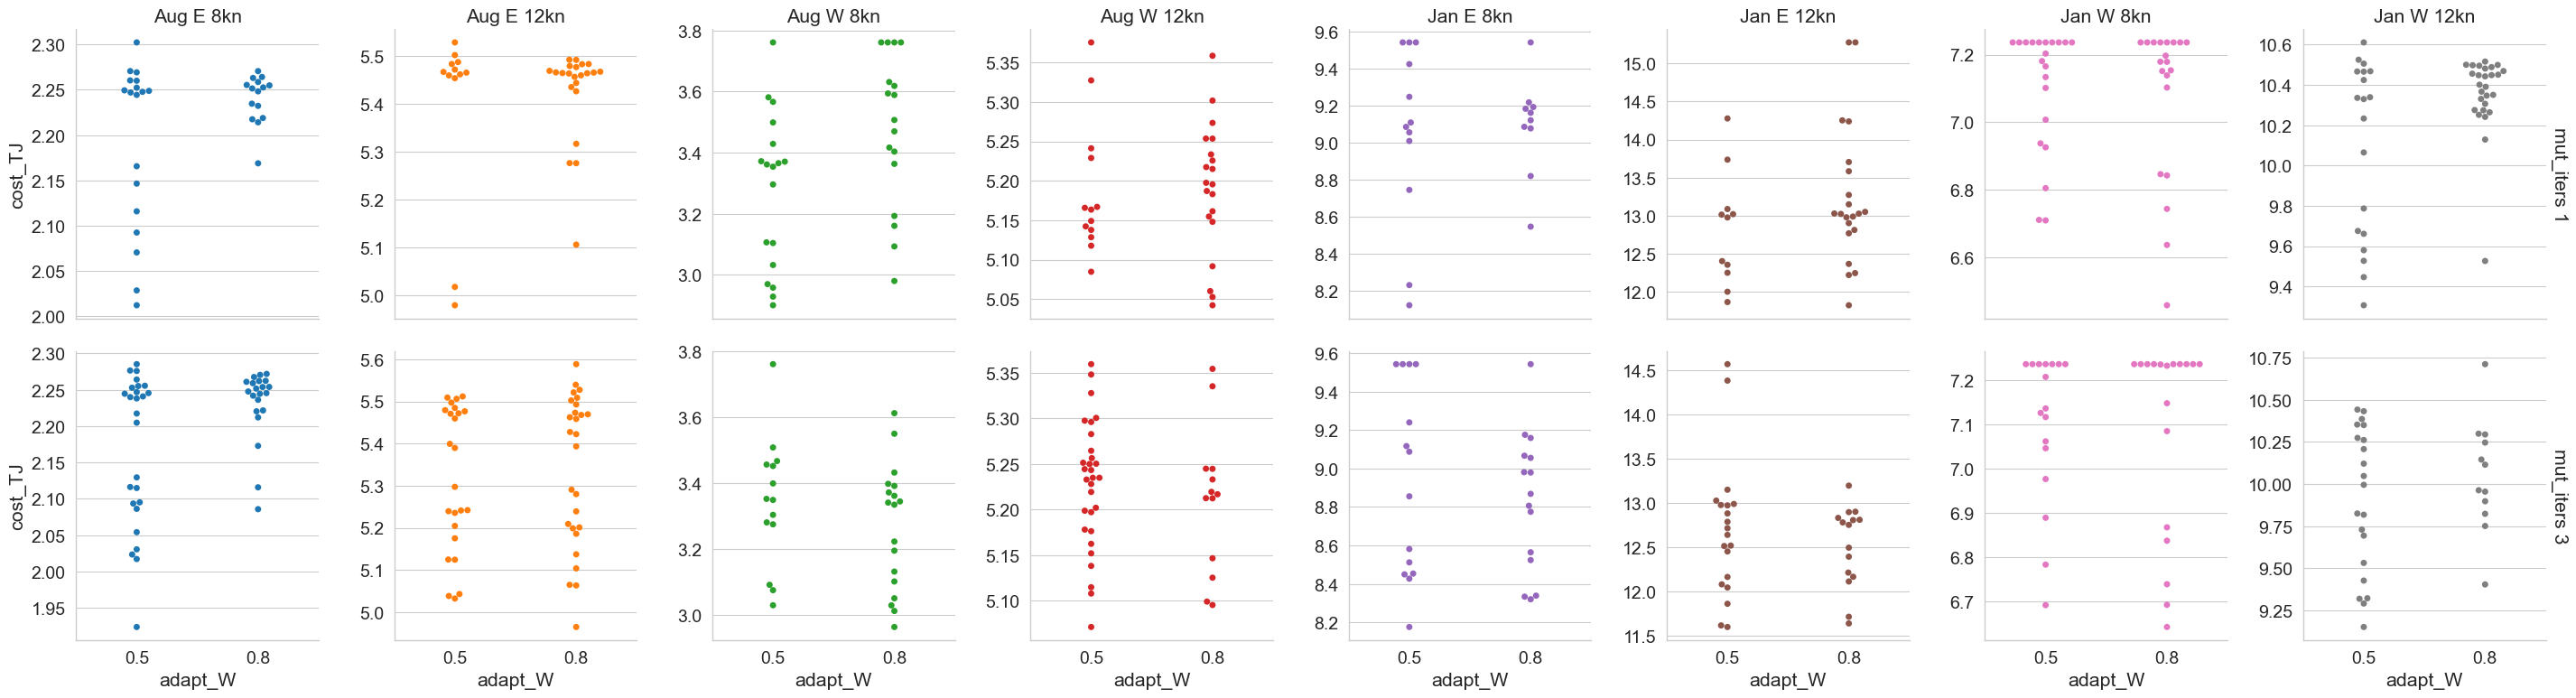

In [13]:
adapt_df = gen_only[gen_only.hyper_enable_adaptation == True].copy()
adapt_df["adapt_W"] = ordered_cat(adapt_df.hyper_adaptation_scale_W.round(1))
adapt_df["mut_iters"] = ordered_cat(adapt_df.hyper_mutation_iterations.astype(int))

g = sns.catplot(
    data=adapt_df,
    x="adapt_W",
    y="cost_TJ",
    hue="case",
    col="case",
    row="mut_iters",
    kind="swarm",
    height=4,
    aspect=0.9,
    sharey=False,
    legend=False,
    palette=CASE_PALETTE,
    margin_titles=True,
)
g.set_titles(col_template="{col_name}", row_template="mut_iters {row_name}")
g.tight_layout()
g.savefig(f"{FIG_DIR}/031_cond_adapt_W_x_mut.png", dpi=150)
g.savefig(f"{FIG_DIR}/031_cond_adapt_W_x_mut.pdf", dpi=150)

### 4d: crossover_strategy (crossover_rounds > 0 only)

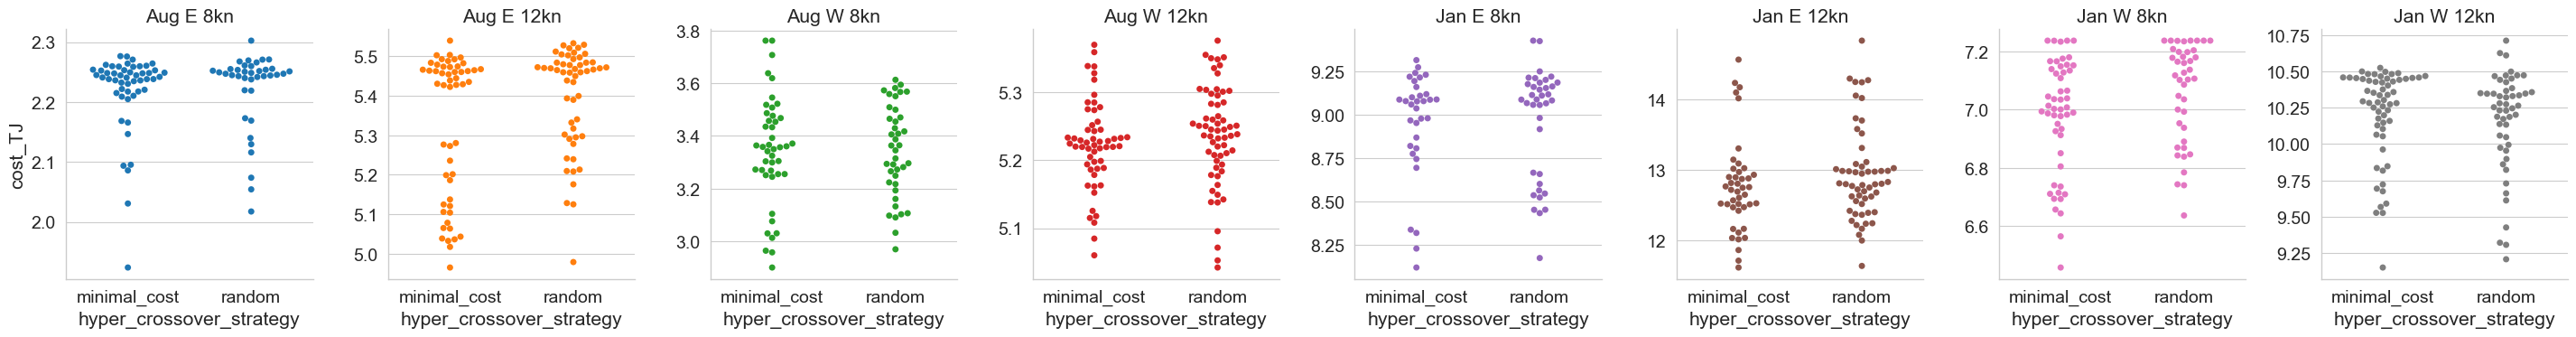

In [14]:
xover_df = gen_only[gen_only.hyper_crossover_rounds > 0].copy()

g = sns.catplot(
    data=xover_df,
    x="hyper_crossover_strategy",
    y="cost_TJ",
    hue="case",
    col="case",
    kind="swarm",
    height=4,
    aspect=0.9,
    sharey=False,
    legend=False,
    palette=CASE_PALETTE,
)
g.set_titles(col_template="{col_name}")
g.tight_layout()
g.savefig(f"{FIG_DIR}/031_cond_xover_strategy.png", dpi=150)
g.savefig(f"{FIG_DIR}/031_cond_xover_strategy.pdf", dpi=150)